For this notebook we aim to answer only one question:
"How well does the best saved model generalize to completely unseen data?"

In [1]:
import os
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
)

from tqdm.auto import tqdm

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import sys
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Malaria-Cell-Classification"
)

sys.path.append(str(PROJECT_DIR))

from src import (
    MalariaDataPreprocessor,
    MalariaCNN,
    ModelEvaluator,
)

In [4]:
PROJECT_CONFIG = {

    "project_dir": PROJECT_DIR,

    "batch_size": 32,

    "device": (
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    ),

    "checkpoint_path":
        PROJECT_DIR
        / "checkpoints"
        / "best_model.pth",

    "outputs_dir":
        PROJECT_DIR
        / "outputs",
}

In [5]:
preprocessor = MalariaDataPreprocessor(
    project_dir=PROJECT_CONFIG["project_dir"],
    batch_size=PROJECT_CONFIG["batch_size"],
)

preprocessor.prepare()

Dataset already extracted.

Dataset validation successful.
Dataset Location : /content/drive/MyDrive/Malaria-Cell-Classification/dataset/extracted/cell_images
Classes Found    : ['Parasitized', 'Uninfected']
Dataset Metadata
Total Images : 27558

   image_id                                           filepath  \
0         0  /content/drive/MyDrive/Malaria-Cell-Classifica...   
1         1  /content/drive/MyDrive/Malaria-Cell-Classifica...   
2         2  /content/drive/MyDrive/Malaria-Cell-Classifica...   
3         3  /content/drive/MyDrive/Malaria-Cell-Classifica...   
4         4  /content/drive/MyDrive/Malaria-Cell-Classifica...   

                                        filename   class_name  label  width  \
0  C100P61ThinF_IMG_20150918_144104_cell_162.png  Parasitized      1    142   
1  C100P61ThinF_IMG_20150918_144104_cell_163.png  Parasitized      1    148   
2  C100P61ThinF_IMG_20150918_144104_cell_164.png  Parasitized      1    139   
3  C100P61ThinF_IMG_20150918_144104_cell

Dataset Preparation for Evaluation

The same preprocessing pipeline used during training is executed to ensure that the test dataset undergoes identical transformations and normalization. Because a fixed random seed is used during dataset splitting, the same train, validation, and test partitions are reproduced, ensuring consistency between the training and evaluation stages.

In [6]:
# ---------------------------------------------------
# Build model
# ---------------------------------------------------

model = MalariaCNN(
    input_channels=3,
    num_classes=2,
    conv_channels=[32, 64, 128],
    kernel_size=3,
    dropout=0.30,
    activation="relu",
    use_batchnorm=True,
)

# ---------------------------------------------------
# Load trained weights
# ---------------------------------------------------

checkpoint = torch.load(
    PROJECT_CONFIG["checkpoint_path"],
    map_location=PROJECT_CONFIG["device"],
)

model.load_state_dict(checkpoint["model_state_dict"])

# ---------------------------------------------------
# Move model to device
# ---------------------------------------------------

model.to(PROJECT_CONFIG["device"])

# ---------------------------------------------------
# Evaluation mode
# ---------------------------------------------------

model.eval()

print("✓ Trained model loaded successfully.")

✓ Trained model loaded successfully.


In [7]:
criterion = torch.nn.CrossEntropyLoss()

In [8]:
evaluator = ModelEvaluator(
    model=model,
    dataloader=preprocessor.test_loader,
    criterion=criterion,
    device=PROJECT_CONFIG["device"],
    class_names=[
        "Uninfected",
        "Parasitized",
    ],
    output_dir=PROJECT_CONFIG["outputs_dir"],
)

In [9]:
metrics = evaluator.evaluate()

metrics

Evaluating:   0%|          | 0/130 [00:00<?, ?it/s]

{'loss': 0.1561420478528689,
 'accuracy': 0.9472665699080793,
 'precision': 0.9802597402597403,
 'recall': 0.9129172714078374,
 'f1': 0.9453907815631263}

In [10]:
evaluator.summary()

              Model Evaluation Summary
Loss       : 0.1561
Accuracy   : 0.9473
Precision  : 0.9803
Recall     : 0.9129
F1 Score   : 0.9454

Test Samples : 4134
Output Directory : /content/drive/MyDrive/Malaria-Cell-Classification/outputs


In [11]:
# ---------------------------------------------------
# Classification Report
# ---------------------------------------------------

print(evaluator.classification_report())

              precision    recall  f1-score   support

  Uninfected     0.9185    0.9816    0.9490      2067
 Parasitized     0.9803    0.9129    0.9454      2067

    accuracy                         0.9473      4134
   macro avg     0.9494    0.9473    0.9472      4134
weighted avg     0.9494    0.9473    0.9472      4134



**Classification Report**

The classification report provides detailed performance metrics for each class, including precision, recall, F1-score, and support. Unlike overall accuracy, these metrics reveal how well the model distinguishes between parasitized and uninfected cells individually and help identify whether one class is more difficult to classify than the other.

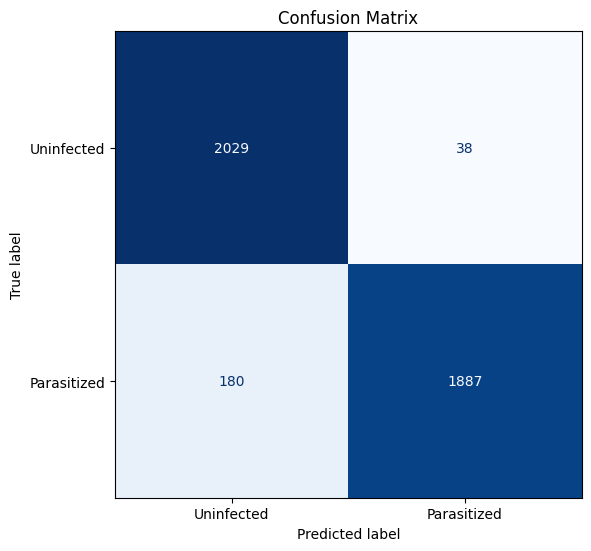

In [12]:
# ---------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------

fig = evaluator.confusion_matrix()

plt.show()

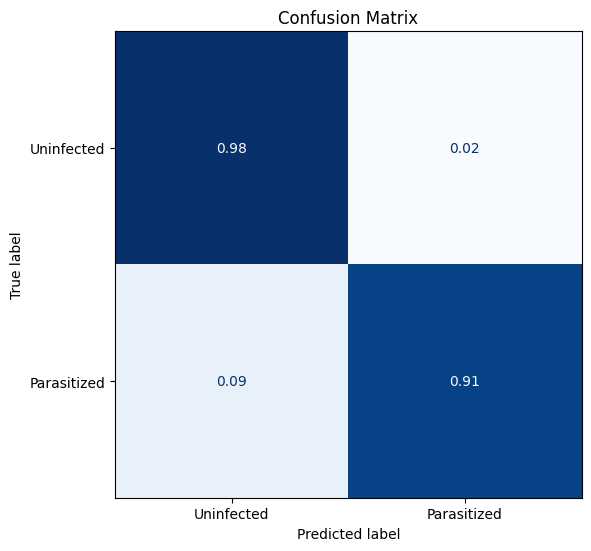

In [13]:
fig = evaluator.confusion_matrix(normalize="true")

plt.show()

**Confusion Matrix**

The confusion matrix summarizes the model's predictions by comparing the predicted labels against the true labels. The diagonal elements represent correctly classified samples, while the off-diagonal elements represent misclassifications. This visualization helps identify the types of errors made by the classifier.

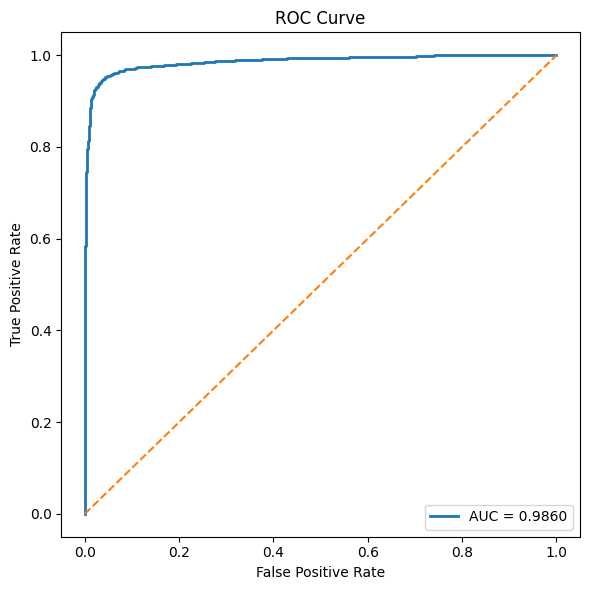

In [14]:
# ---------------------------------------------------
# ROC Curve
# ---------------------------------------------------

fig = evaluator.roc_curve()

plt.show()

**Receiver Operating Characteristic (ROC) Curve**

The ROC curve illustrates the trade-off between the True Positive Rate (Sensitivity) and the False Positive Rate at different classification thresholds. The Area Under the Curve (AUC) provides a threshold-independent measure of model performance, with values closer to 1.0 indicating better discrimination between classes.

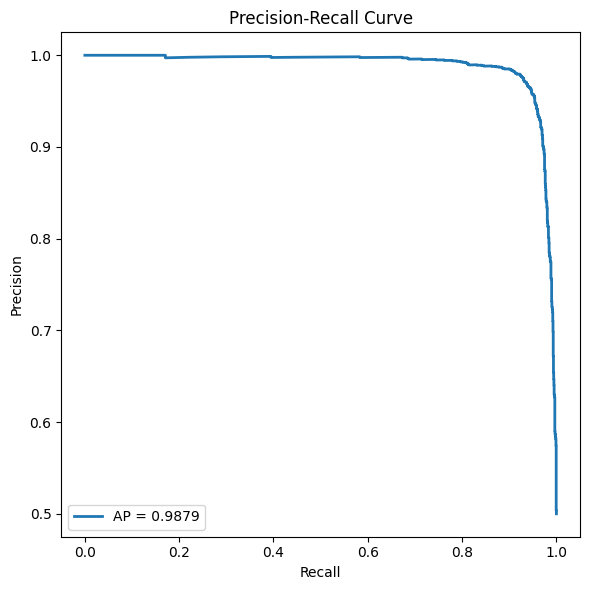

In [15]:
# ---------------------------------------------------
# Precision-Recall Curve
# ---------------------------------------------------

fig = evaluator.precision_recall_curve()

plt.show()

**Precision–Recall Curve**

The Precision–Recall curve is particularly useful for medical image classification because it emphasizes the relationship between correctly identifying positive cases and minimizing false positives. This visualization becomes especially informative when dealing with imbalanced datasets.

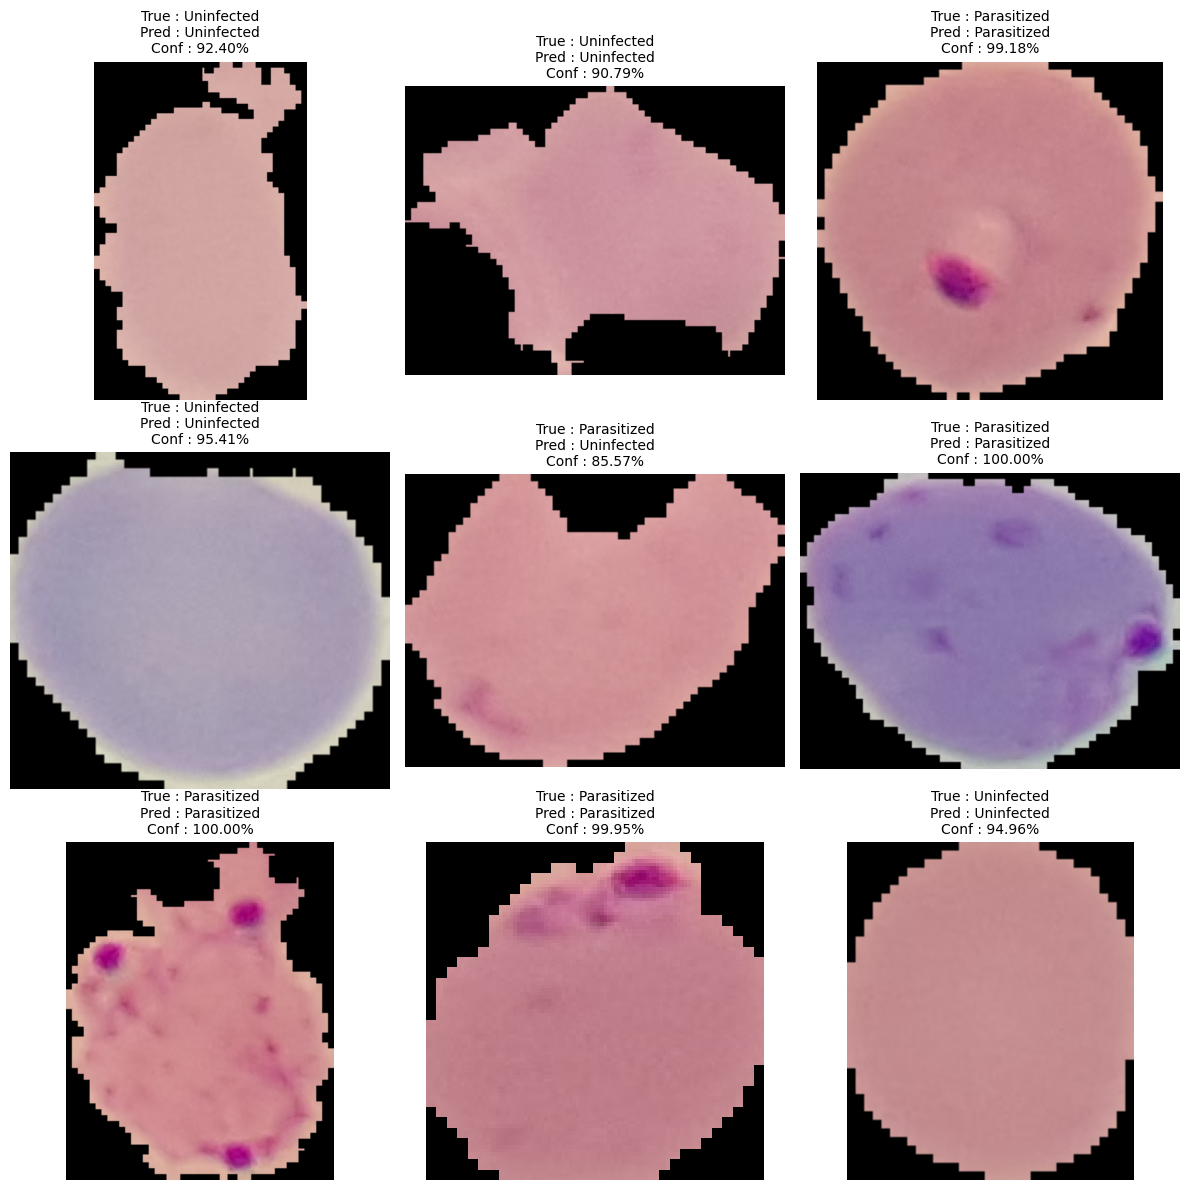

In [16]:
fig = evaluator.sample_predictions(
    dataframe=preprocessor.test_df,
    n=9,
)

plt.show()

**Sample Predictions**

Random samples from the test dataset are displayed together with the predicted class, true class, and prediction confidence. This qualitative inspection helps verify that the model is making sensible decisions and provides insight into cases where the model may be uncertain or incorrect.

In [17]:
# ---------------------------------------------------
# Save Evaluation Results
# ---------------------------------------------------

evaluator.save_results()

Evaluation results saved to:
/content/drive/MyDrive/Malaria-Cell-Classification/outputs


In [18]:
# ---------------------------------------------------
# Evaluation Results
# ---------------------------------------------------

results_df = evaluator.get_results()

results_df.head()

,image_id,true_label,prediction,prob_uninfected,prob_parasitized,confidence
0,16883,0,0,0.898432,0.101568,0.898432
1,7810,1,1,0.001474,0.998526,0.998526
2,20017,0,0,0.920911,0.079089,0.920911
3,40,1,1,0.007185,0.992815,0.992815
4,18789,0,0,0.955958,0.044042,0.955958


In [19]:
# ---------------------------------------------------
# Evaluation Summary
# ---------------------------------------------------

evaluator.summary()

              Model Evaluation Summary
Loss       : 0.1561
Accuracy   : 0.9473
Precision  : 0.9803
Recall     : 0.9129
F1 Score   : 0.9454

Test Samples : 4134
Output Directory : /content/drive/MyDrive/Malaria-Cell-Classification/outputs


### **Evaluation Notebook Summary** ###

The trained CNN model was evaluated on the held-out test dataset using the same preprocessing pipeline applied during training. The evaluation included quantitative metrics such as accuracy, precision, recall, F1-score, ROC and Precision–Recall curves, together with qualitative inspection through sample predictions.

The evaluation artifacts—including prediction probabilities, classification reports, and performance metrics—have been saved to the project's output directory. These outputs provide a comprehensive assessment of the model's generalization performance and establish a strong foundation for the next phase of the project: deploying the trained model as a web application capable of classifying new malaria cell images uploaded by users.